# Prevendo atrasos de voos

In [1]:
# Importando bibliotecas
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
# Importando a base de dados
df = pd.read_csv('airlines.csv', sep = ',')

In [3]:
# Olhando as primeira linhas
df.head()

,Flight,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek,Class
0,2313.0,1296.0,141.0,DL,ATL,HOU,1,0
1,6948.0,360.0,146.0,OO,COS,ORD,4,0
2,1247.0,1170.0,143.0,B6,BOS,CLT,3,0
3,31.0,1410.0,344.0,US,OGG,PHX,6,0
4,563.0,692.0,98.0,FL,BMI,ATL,4,0


In [4]:
# Verificando linhas e colunas
df.shape

(539382, 8)

## Analisando a consistência dos dados 
#### Vamos validar se o dataset contém dados nulos e valores duplicados

In [5]:
# Verificando valores nulos
df.isnull().sum()

Flight         0
Time           0
Length         0
Airline        0
AirportFrom    0
AirportTo      0
DayOfWeek      0
Class          0
dtype: int64

In [6]:
# Limpando dados nulos
df = df.dropna

#### Não temos nenhum valor nulo na base de dados

In [7]:
# Recarregando a base para garantir que a variável seja um DataFrame
import pandas as pd

airlines_df = pd.read_csv('airlines.csv', sep=',')

print(type(airlines_df))
print(airlines_df.shape)

# Verificando valores duplicados por coluna
duplicated_cols = []

for col in airlines_df.columns:
    if airlines_df[col].duplicated().any():
        duplicated_cols.append(col)

print("Colunas com valores duplicados:")
print(duplicated_cols)

<class 'pandas.DataFrame'>
(539382, 8)
Colunas com valores duplicados:
['Flight', 'Time', 'Length', 'Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Class']


#### Após a análise, podemos considerar o comportamento normal, pois podemos ter vários casos com o mesmo valor na base

## Análise exploratória

In [8]:
import pandas as pd

df = pd.read_csv('airlines.csv', sep=',')

print(type(df))
print(df.shape)

# Analisando a descrição dos dados 
df.describe()

<class 'pandas.DataFrame'>
(539382, 8)


,Flight,Time,Length,DayOfWeek,Class
count,539382.000000,539382.000000,539382.000000,539382.000000,539382.000000
mean,2427.927988,802.728161,132.202104,3.929666,0.445443
std,2067.431700,278.045546,70.117045,1.914666,0.497015
min,1.000000,10.000000,0.000000,1.000000,0.000000
25%,712.000000,565.000000,81.000000,2.000000,0.000000
50%,1809.000000,795.000000,115.000000,4.000000,0.000000
75%,3745.000000,1035.000000,162.000000,5.000000,1.000000
max,7814.000000,1439.000000,655.000000,7.000000,1.000000


#### Inferência 
##### - Média de duração de voos é de 133
##### - Desvio padrão de 70
##### Se o desvio padrão é baixo em relação a média, isso significa que a maiorida dos valores estão próximos a média e que os dados estão mais concetrados em torno da média. 

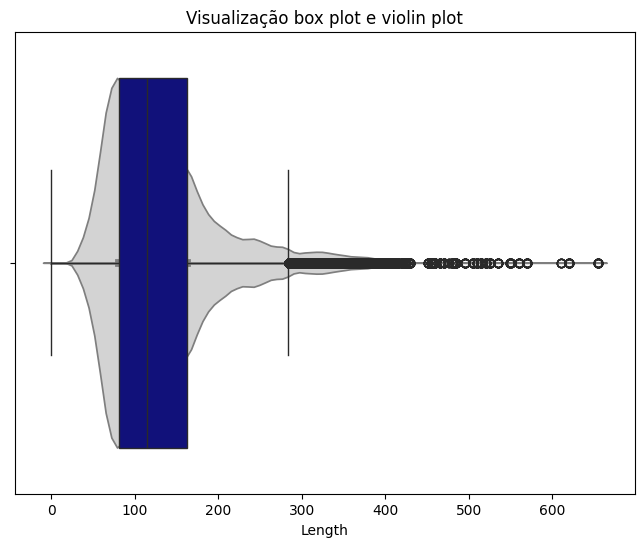

In [9]:
# Analisando o tempo do voo utilizando gráfico de violino em conjunto com o boxplot
fig, ax = plt.subplots(figsize = (8,6))

# Configurando o violin plot
sns.violinplot(x = 'Length', data = df, ax = ax, color = 'lightgray')

# Criando um boxplot
sns.boxplot(x = 'Length', data = df, ax = ax, color = 'darkblue')
ax.set_title('Visualização box plot e violin plot')

# Plotando o gráfico
plt.show()

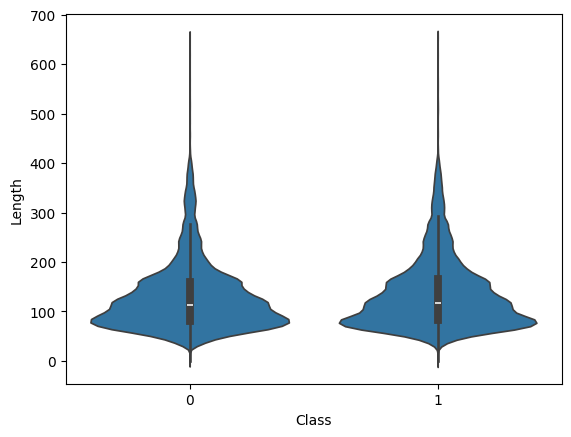

In [10]:
# Analisando o tempo do voo utilizando gráfico de violino em conjunto com o boxplot, separando por classe
sns.violinplot(x = 'Class', y = 'Length', data = df)
plt.show()

In [11]:
# Verificando a média de duração dos voos 
atraso_voo = df.groupby('Class')
atraso_voo.describe().T

Class                        0              1
Flight    count  299118.000000  240264.000000
          mean     2513.484842    2321.413508
          std      2102.883185    2017.368082
          min         1.000000       1.000000
          25%       725.000000     701.000000
          50%      1924.000000    1695.000000
          75%      3931.000000    3408.000000
          max      7812.000000    7814.000000
Time      count  299118.000000  240264.000000
          mean      765.235138     849.405308
          std       283.712464     263.472137
          min        10.000000      10.000000
          25%       515.000000     640.000000
          50%       735.000000     860.000000
          75%       998.000000    1060.000000
          max      1439.000000    1439.000000
Length    count  299118.000000  240264.000000
          mean      129.657760     135.369697
          std        68.693953      71.723475
          min         0.000000       0.000000
          25%        81.000000      82.000000
          50%       114.000000     118.000000
          75%       159.000000     166.000000
          max       655.000000     655.000000
DayOfWeek count  299118.000000  240264.000000
          mean        3.974622       3.873697
          std         1.907565       1.922004
          min         1.000000       1.000000
          25%         2.000000       2.000000
          50%         4.000000       4.000000
          75%         5.000000       5.000000
          max         7.000000       7.000000

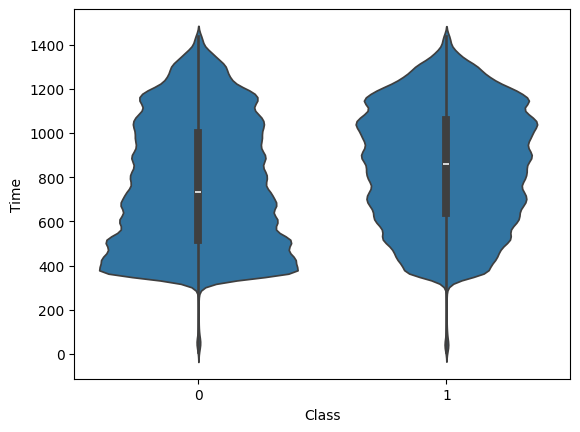

In [12]:
# Analisando o comportamento do time
sns.violinplot(x = 'Class', y = 'Time', data = df)
plt.show()

<Axes: xlabel='Airline', ylabel='count'>

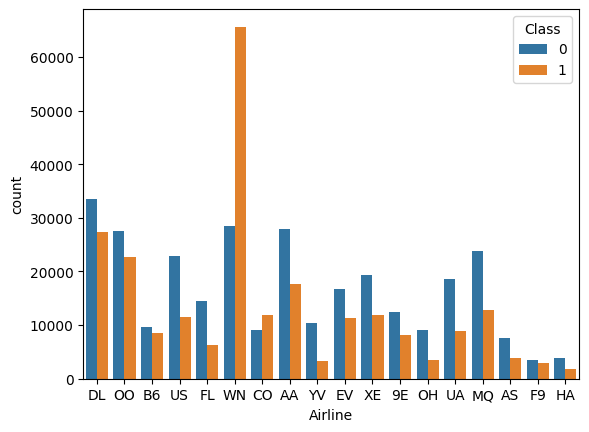

In [13]:
# Verificando companhias X atrasos de voos
sns.countplot(x = 'Airline', hue = 'Class', data = df)

<Axes: xlabel='DayOfWeek', ylabel='count'>

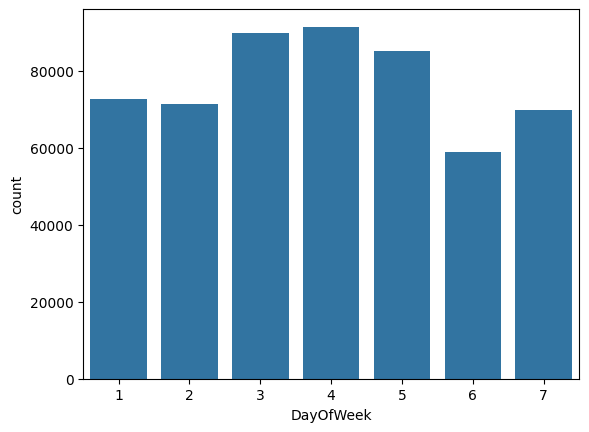

In [14]:
# Analisando os dias de semana que possuem maior concentração de atraso
diaSemana = list(range(1,8))
sns.countplot(x = 'DayOfWeek', data = df, order = diaSemana)

<Axes: xlabel='Class', ylabel='count'>

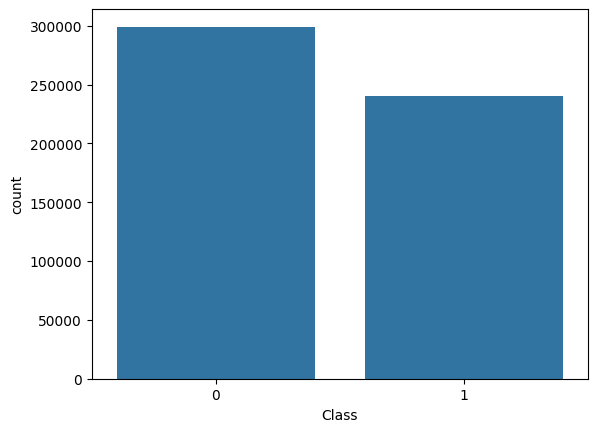

In [15]:
# Verficando equilíbrio entre números de atrasos e não atrasos
sns.countplot(x = 'Class', data = df)

## Pré-processamento da base
### Para utilizar a companhia aérea dentro do modelo, iremos realiar a transformação da label encoding nos dados

In [16]:
%pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [17]:
df.head()

,Flight,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek,Class
0,2313.0,1296.0,141.0,DL,ATL,HOU,1,0
1,6948.0,360.0,146.0,OO,COS,ORD,4,0
2,1247.0,1170.0,143.0,B6,BOS,CLT,3,0
3,31.0,1410.0,344.0,US,OGG,PHX,6,0
4,563.0,692.0,98.0,FL,BMI,ATL,4,0


In [18]:
from sklearn.preprocessing import LabelEncoder

In [19]:
# Transformando as variáveis categóricas em numéricas utilizando LabelEncoder
df['AirportFrom'] = LabelEncoder().fit_transform(df['AirportFrom'])
df['AirportTo'] = LabelEncoder().fit_transform(df['AirportTo'])

In [20]:
# Transformando a variável Airline em numérica utilizando LabelEncoder
df['Airline'] = LabelEncoder().fit_transform(df['Airline'])

In [21]:
df.head(4)

,Flight,Time,Length,Airline,AirportFrom,AirportTo,DayOfWeek,Class
0,2313.0,1296.0,141.0,5,16,129,1,0
1,6948.0,360.0,146.0,12,65,208,4,0
2,1247.0,1170.0,143.0,3,35,60,3,0
3,31.0,1410.0,344.0,14,203,217,6,0


### Separando a base de dados

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
# Separando as variáveis independentes (X) e a variável dependente (y)
x = df[['Flight', 'Airline', 'AirportFrom', 'AirportTo', 'DayOfWeek', 'Time', 'Length']]
y = df['Class']

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 7)

### Criando o modelo naive bayes
#### Ele é um algoritimo baseado no teorema de Bayes e na suposição de independência condicional entre atributos. 
#### O modelo naive bayes calcula a probabilidade condicional de uma determinada classe, dada a uma entrada de dados ou conjuntos de atributos, utilizando a regra de bayes.
#### Ele assume que os atributos de entrada são independentes entre si, ou seja, a presença ou ausência de um atributo não é afetada pela presença ou ausência de outro atributo.  

In [25]:
# Importando a biblioteca
from sklearn.naive_bayes import GaussianNB

In [26]:
# Preparando os dados pra rodar o modelo
gnb = GaussianNB()
gnb.fit(x_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [27]:
# Criando e treinando o modelo Naive Bayes com os dados de treino
y_pred = gnb.predict(x_test)

## Validando o modelo

In [28]:
# Importando a função para calcular a acurácia do modelo
from sklearn.metrics import accuracy_score

In [29]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy,2))

Accuracy: 0.59


#### O modelo não obteve um preditivo muito grande, podendo ter alguns impeditivos como: quantidade insuficiente de dados, dados de treinamento não representativos, dados de baixa qualidade ou até mesmo caracteristicas irrelevantes. 

## Equilibrando a base de dados
#### Para equilibrar a bae de dados, podemos utilizar algumas técnicas como por exemplo a biblioteca resample do sklearn.utilits, utilizando o oversampling. 
#### O oversampling é o processo de duplicar ou criar novas amostras da classe minoritária, enquanto o undersampling é o processo de remover algumas amostras da classe majoritária. 

In [30]:
from sklearn.utils import resample

In [31]:
# Separando as classes majoritárias e minoritárias
df_majority = df[df.Class == 0]
df_minority = df[df.Class == 1]

In [32]:
len(df_majority)

299118

In [33]:
# Upsampling da classe minoritária 
df_minority_upsampled = resample(df_minority, replace = True, n_samples=len(df_minority), random_state = 7)

In [34]:
# Jutando os dois DF
df_equilibrado = pd.concat([df_majority, df_minority_upsampled])

<Axes: xlabel='Class', ylabel='count'>

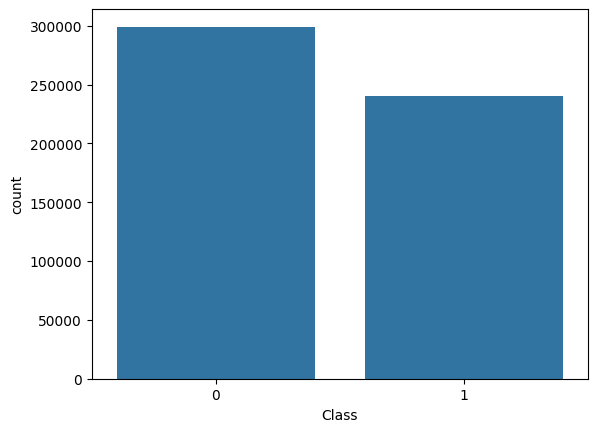

In [35]:
sns.countplot(x = 'Class', data = df_equilibrado)

## Testando o algoritmo com a base equilibrada

In [36]:
x_equilibrado = df_equilibrado[['Flight', 'Time', 'Length', 'DayOfWeek']]
y_equilibrado = df_equilibrado['Class']

In [41]:
# Dividindo os dados equilibrados em treino e teste
x_train, x_test, y_train, y_test = train_test_split(
    x_equilibrado,
    y_equilibrado,
    test_size=0.3,
    stratify=y_equilibrado,
    random_state=7
)

# Treinando o algoritmo
gnb_equilibrado = GaussianNB()
gnb_equilibrado.fit(x_train, y_train)

# Predizendo os valores
y_pred_gnb_equilibrado = gnb_equilibrado.predict(x_test)

# Validando o modelo
accuracy_equilibrado = accuracy_score(y_test, y_pred_gnb_equilibrado)
print("Accuracy:", round(accuracy_equilibrado, 2))

Accuracy: 0.57


#### Ficou pior que o primeiro modelo, podendo ser ajustado com um novo modelo

## Testando com o Random Forest
#### Ele cria forma aleatória de várias àrvores de decisão e combina o resutlado de todas elas para cgegar no resultado final. 
#### Vamos analisar se combia uma base dados equilibrada com um algoritmo diferente e poderoso de classificação pode melhorar o resultado final.

In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
x_train, x_test, y_train, y_test = train_test_split(x_equilibrado, y_equilibrado, test_size=0.3, random_state=7)

In [44]:
# Instanciando o modelo Random Forest e definindo os hiperparâmetros
rf = RandomForestClassifier(random_state=7)

In [45]:
# Treinando o modelo com o conjunto de treinamento
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [46]:
# Fazendo previsões no conjunto de teste
y_pred_rf = rf.predict(x_test)

In [47]:
# Validando o modelo
accuracy_equilibrado_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", round(accuracy_equilibrado_rf,2))

Accuracy: 0.69
